# EXIT Curve Experiments for CSS Codes

This notebook estimates two finite-length curve families for the quantum erasure channel:

1. Exact kernel/rank curves: raw X-error entropy `H(x_E | E,S)` and X-correction-class entropy `H(C_X | E,S)`.
2. Algorithmic peeling curves: unassisted X-side guess bits `H_peel(x_E | E,S)`, stabilizer-aided guess bits `H_peel(C_X | E,S)`, and their difference.

For now this notebook plots one CSS component. The exact correction-class entropy `H(C_X | E, S)` is the target quantity for the one-sided EXIT curve. The peeling curves are algorithmic proxies: `H_peel(x_E | E,S)` approximates raw X-side guessing without stabilizer aid, while `H_peel(C_X | E,S)` approximates the remaining class entropy after stabilizer aid.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'experiments':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'experiments'))

from exit_curve_experiments import (
    load_code,
    representative_runs,
    run_code,
    write_outputs,
    plot_result,
)

codes = sorted((ROOT / 'codes').glob('*.npz'), key=lambda p: p.stat().st_size)
[(p.name, load_code(p).n, load_code(p).k, representative_runs(load_code(p).n)) for p in codes]

[('surface5_HxHzLxLz.npz', 41, 1, 5000),
 ('surface7_HxHzLxLz.npz', 85, 1, 3000),
 ('surface9_HxHzLxLz.npz', 145, 1, 1500),
 ('gross_HxHzLxLz.npz', 144, 12, 1500),
 ('surface11_HxHzLxLz.npz', 221, 1, 1500),
 ('two_gross_HxHzLxLz.npz', 288, 12, 1000),
 ('hgp625.npz', 625, 25, 400),
 ('B1_HxHzLxLz.npz', 882, 24, 200)]

## Run One Code

Start with the smallest code. Increase `runs` after confirming runtime and curve shape. Use `use_rule2=False` for surface-code rule-1-only experiments.

In [2]:
code_path = ROOT / 'codes' / 'surface5_HxHzLxLz.npz'
ps = [i / 50 for i in range(51)]
runs = 1000

result = run_code(
    code_path,
    ps,
    runs,
    seed=0,
    include_exact=True,
    include_peeling=True,
    use_rule2=False,
)
result['code'], result['elapsed_seconds']

({'path': 'c:\\Users\\User\\Documents\\projects-git\\giulio-main\\giulio-main\\stabilizer-inactivation-decoding\\codes\\surface5_HxHzLxLz.npz',
  'name': 'surface5_HxHzLxLz',
  'n': 41,
  'rank_hx': 20,
  'rank_hz': 20,
  'k': 1,
  'rate': 0.024390243902439025},
 270.6713618999929)

In [3]:
out_dir = ROOT / 'data' / 'experiments' / 'exit_curves'
json_path, csv_path = write_outputs(result, out_dir)
plot_path = plot_result(result, out_dir)
json_path, csv_path, plot_path

(WindowsPath('c:/Users/User/Documents/projects-git/giulio-main/giulio-main/stabilizer-inactivation-decoding/data/experiments/exit_curves/surface5_HxHzLxLz_exit_rule1.json'),
 WindowsPath('c:/Users/User/Documents/projects-git/giulio-main/giulio-main/stabilizer-inactivation-decoding/data/experiments/exit_curves/surface5_HxHzLxLz_exit_rule1.csv'),
 WindowsPath('c:/Users/User/Documents/projects-git/giulio-main/giulio-main/stabilizer-inactivation-decoding/data/experiments/exit_curves/surface5_HxHzLxLz_exit_rule1.png'))

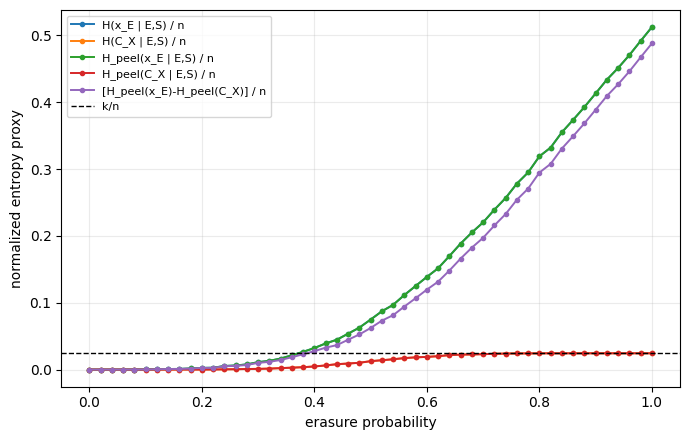

In [4]:
import matplotlib.pyplot as plt

points = result['points']
p = [pt['p'] for pt in points]

fig, ax = plt.subplots(figsize=(7, 4.5))
for key, label in [
    ('exact_x_error_component_norm', 'H(x_E | E,S) / n'),
    ('exact_x_class_component_norm', 'H(C_X | E,S) / n'),
    ('peel_x_unassisted_guess_component_norm', 'H_peel(x_E | E,S) / n'),
    ('peel_x_aided_guess_component_norm', 'H_peel(C_X | E,S) / n'),
    ('peel_x_saved_guess_component_norm', '[H_peel(x_E)-H_peel(C_X)] / n'),
]:
    ax.plot(p, [pt[key] for pt in points], marker='.', linewidth=1.4, label=label)
ax.axhline(result['code']['rate'], color='black', linestyle='--', linewidth=1, label='k/n')
ax.set_xlabel('erasure probability')
ax.set_ylabel('normalized entropy proxy')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()

## Endpoint and Area Sanity Checks

`exact_x_class = H(C_X | E,S)` should start near `0` bits and end near `k` bits. The component-normalized curve `exact_x_class_component_norm = H(C_X | E,S)/n` ends at `k/n`. The area theorem applies to the derivative of this normalized entropy curve.

In [5]:
import numpy as np

b = np.array([pt['exact_x_class_component_norm'] for pt in points])
p_arr = np.array(p)
h_q = np.gradient(b, p_arr)
area = np.trapezoid(h_q, p_arr)
{'H(C_X|E,S)/n at p=0': b[0], 'H(C_X|E,S)/n at p=1': b[-1], 'area_estimate': area, 'k/n': result['code']['rate'], 'area_metadata': result['areas']['exact_x_class_component_norm']}

{'H(C_X|E,S)/n at p=0': np.float64(0.0),
 'H(C_X|E,S)/n at p=1': np.float64(0.024390243902439025),
 'area_estimate': np.float64(0.02439024390243903),
 'k/n': 0.024390243902439025,
 'area_metadata': {'endpoint_delta': 0.024390243902439025,
  'trapezoid_derivative_area': 0.02439024390243903,
  'value_at_p0': 0.0,
  'value_at_p1': 0.024390243902439025}}